## 1. Introducción
Utilizando el código de multiplicación de matrices "mul_mat.c" utilizando **OpenMP** evaluaremos el rendimiento entre núclos de rendimiento y núcles de eficiencia. Al tener una mayor número de núcles de eficiencia que de rendimiento evaluaremos en cual de los dos contextos se obtiene un mejor resultado en términos de tiempo.


### Objetivos:
* Ejecutar el código "mul_mat.c" (multiplicación de matrices) solo en los núcles de eficiencia. 
* Ejecutar el código "mul_mat.c" (multiplicación de matrices) solo en los núcles de rendimiento. 
* Analizar los tiempos de ejecución obtenidos de las ejecuciones anteriores.

## 2. Caracterización del entorno de Cómputo
Listado de las especificaciónes técnicas de la plataforma de ejecución:
* **Procesador:** Apple M4
* **Arquitectura:** arm64
* **Nucleos totales:** 10
*  **Núcleos de eficiencia:** 4
* **Núcleos de rendimiento:** 6

## 3. Implementación y Entorno de ejecución
### 3.1 Configuración del compilador 

Dado que se esta trabajando en una arquitectura **Apple M4**, se utiliza el compilador de `clang` y la librería `libomp` instalada con Homebrew.

Se realizo una variable de entorno en el archivo `.zshrc` para poder realizar la compilación con el soporte de **OpenMP:** 


```
gcc-omp() {
    local file=$1
    local output="${file%.*}"
    clang -Xpreprocessor -fopenmp -lomp \
    -I$(brew --prefix libomp)/include \
    -L$(brew --prefix libomp)/lib \
    "$@" -o "$output"
}
```

Con lo que ahora para compilar nuestro código fuente solo necesitamos hacer el comando `gcc-omp <file.c> -O3`.

### 3.2 Variables de entorno (OpenMP)
Para la ejecución del programo se tienen que configurar las varibles de entorno dependiendo de si queremos utilizar los núcleos de rendimiento o de eficiencia la configuración es la siguiente:


**Núcleos de eficiencia:**

In [45]:
%%capture
%env OMP_NUM_THREADS=6
%env OMP_WAIT_POLICY=PASSIVE

**Núcleos de rendimiento:**

In [46]:
%%capture
%env OMP_NUM_THREADS=4
%env OMP_WAIT_POLICY=ACTIVE;

> Nota:
> 
> A diferencia de los entornos Linux, donde es posible forzar la ejecución de hilos en núcleos específicos mediante herramientas como taskset o variables como GOMP_CPU_AFFINITY, el sistema operativo macOS no permite un control absoluto sobre el mapeo de hardware desde el espacio de usuario.
>
> Consideraciones clave para este reporte:
> * Control del Scheduler: El kernel de Apple (XNU) utiliza políticas de Quality of Service (QoS) para decidir dinámicamente si un hilo se ejecuta en un núcleo de rendimiento (P-core) o de eficiencia (E-core).
> * Limitación de OpenMP: Aunque se utilicen variables como OMP_NUM_THREADS para limitar el conteo de hilos, el sistema operativo se reserva el derecho de mover dichos hilos entre tipos de núcleos según la carga térmica y energética.
> * Estrategia de Mitigación: En este experimento, se utilizan combinaciones de OMP_WAIT_POLICY para "sugerir" la afinidad al sistema.

### 3.3 Código fuente y compilación

El código correspone al de multiplicación de matrices cuadradas `mulMat.c`, las matrices seran de una dimencion de 50000 x 50000. El código fuente `mulMat.c` es el siguiente: 

```c
#include <stdio.h> 
#include <stdlib.h>
#include <omp.h>

#define N 11000

double *a, *b, *c; 

void multiplicaMatricesCuadradas(double *a, double *b, double *c, int n) {
    int i, j, k; 
    double tmp; 

    #pragma omp parallel for private (j, k, tmp)
    for (i=0; i<n; i++) {
	tmp = 0.0;
       for (j=0; j<n; j++) {
         tmp += b[i*n+j]*c[j]; 
       }
	a[i] = tmp;
    }

}


int main(int argc, char **argv) {
    int i, j; 
    int m, n; 
    double t0, t1, t2, t3; 

    t0 = omp_get_wtime();

    n = (argc > 1)?atoi(argv[1]): N; 

    a = (double *)malloc(n*n*sizeof(double)); 
    b =	(double *)malloc(n*n*sizeof(double)); 
    c =	(double *)malloc(n*n*sizeof(double)); 

    for (i=0; i<n; i++) {
       for (j=0; j<n; j++) {
          b[i*n+j]=i+j;
       } 
          c[i]= i; 
	  a[i] = 0.0; 
    }

    t1 = omp_get_wtime(); 
    multiplicaMatricesCuadradas(a, b, c, n); 
    t2 = omp_get_wtime(); 

    for (i=n; i<n; i++) { 
           printf("%3.2lf ", a[i]);
    }

    free(a); free(b); free(c);
    t3 = omp_get_wtime();

    printf("Tiempo total de multiplicacin  de matrices de tamanho %d x %d es: %lf\n", 
          n, n, t3-t0);
    printf("Tiempo de creacion e inicializacion de natrices:  %lf\n", t1-t0); 
    printf("Tiempo de multiplicacion efectiva: %lf\n", t2-t1); 
    printf("Tiempo de liberar memoria: %lf\n", t3-t2); 
 
}

In [59]:
%%capture
%env SRC_PATH=/Users/cstobonsosa/Developer/CINVESTAV/HPC/Tareas/Tarea_1_HPC_II/src

In [60]:
%%capture
%env BIN_PATH=/Users/cstobonsosa/Developer/CINVESTAV/HPC/Tareas/Tarea_1_HPC_II/bin

In [49]:
!source ~/.zshrc && gcc-omp $SRC_PATH/mulMat.c -O3 && mv $SRC_PATH/mulMat $BIN_PATH/

## 4.Ejecución

### 4.1 Núcleos de eficiencia
Comenzaremos realizando la ejecución en los núcleos de eficiencia, antes validaremos que nuestras variables de entorno este correctamente configuradas.

In [50]:
!echo "Hilos configurados (OMP_NUM_THREADS): $OMP_NUM_THREADS"
!echo "Política de espera (OMP_WAIT_POLICY): $OMP_WAIT_POLICY"

Hilos configurados (OMP_NUM_THREADS): 4
Política de espera (OMP_WAIT_POLICY): ACTIVE;


In [51]:
import os
from IPython.display import display, Markdown

# Configuración
n_corridas = 4
n_matriz = 50000  

print(f" Iniciando {n_corridas} ejecuciones para N = {n_matriz}...\n")

for i in range(1, n_corridas + 1):
    # Separador visual para identificar cada corrida
    display(Markdown(f"---"))
    display(Markdown(f"### Ejecución Número {i}"))
    
    # Ejecución del binario usando tu variable $BIN_PATH
    !$BIN_PATH/mulMat $n_matriz 50000 

 Iniciando 4 ejecuciones para N = 50000...



---

### Ejecución Número 1

Tiempo total de multiplicacin  de matrices de tamanho 50000 x 50000 es: 6.131695
Tiempo de creacion e inicializacion de natrices:  2.603646
Tiempo de multiplicacion efectiva: 2.891904
Tiempo de liberar memoria: 0.636145


---

...

### Ejecución Número 3

Tiempo total de multiplicacin  de matrices de tamanho 50000 x 50000 es: 5.089263
Tiempo de creacion e inicializacion de natrices:  2.046834
Tiempo de multiplicacion efectiva: 2.463672
Tiempo de liberar memoria: 0.578757


---

### Ejecución Número 4

Tiempo total de multiplicacin  de matrices de tamanho 50000 x 50000 es: 5.062801
Tiempo de creacion e inicializacion de natrices:  2.053855
Tiempo de multiplicacion efectiva: 2.428247
Tiempo de liberar memoria: 0.580699


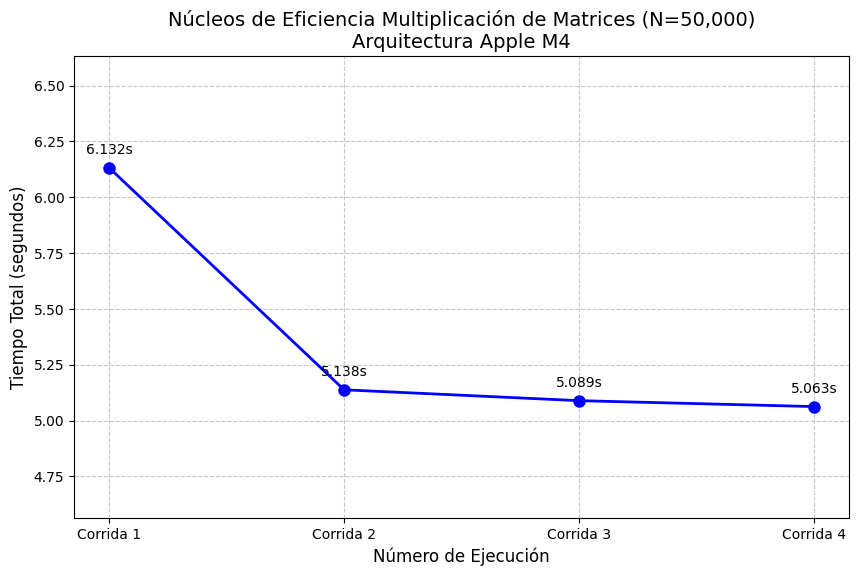

In [57]:
import matplotlib.pyplot as plt

# Datos proporcionados
ejecuciones = ['Corrida 1', 'Corrida 2', 'Corrida 3', 'Corrida 4']
tiempos = [6.131695, 5.137924, 5.089263, 5.062801]

# Configuración de la gráfica
plt.figure(figsize=(10, 6))
plt.plot(ejecuciones, tiempos, marker='o', linestyle='-', color='b', linewidth=2, markersize=8)

# Añadir etiquetas de datos sobre cada punto
for i, txt in enumerate(tiempos):
    plt.annotate(f'{txt:.3f}s', (ejecuciones[i], tiempos[i]), textcoords="offset points", xytext=(0,10), ha='center')

# Estética de la gráfica
plt.title('Núcleos de Eficiencia Multiplicación de Matrices (N=50,000)\nArquitectura Apple M4', fontsize=14)
plt.xlabel('Número de Ejecución', fontsize=12)
plt.ylabel('Tiempo Total (segundos)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.ylim(min(tiempos) - 0.5, max(tiempos) + 0.5) # Ajuste de escala para ver mejor la diferencia

# Mostrar la gráfica
plt.show()

#### 4.2 Núcleos de rendimiento
Ahora es turno de los núcleos de rendimiento, al igual que con los núcleos de eficiencia validaremos que se las variables de entorno esten bien

In [52]:
!echo "Hilos configurados (OMP_NUM_THREADS): $OMP_NUM_THREADS"
!echo "Política de espera (OMP_WAIT_POLICY): $OMP_WAIT_POLICY"

Hilos configurados (OMP_NUM_THREADS): 4
Política de espera (OMP_WAIT_POLICY): ACTIVE;


In [53]:
import os
from IPython.display import display, Markdown

# Configuración
n_corridas = 4
n_matriz = 50000  

print(f" Iniciando {n_corridas} ejecuciones para N = {n_matriz}...\n")

for i in range(1, n_corridas + 1):
    # Separador visual para identificar cada corrida
    display(Markdown(f"---"))
    display(Markdown(f"### Ejecución Número {i}"))
    
    # Ejecución del binario usando tu variable $BIN_PATH
    !$BIN_PATH/mulMat $n_matriz 50000 

 Iniciando 4 ejecuciones para N = 50000...



---

### Ejecución Número 1

Tiempo total de multiplicacin  de matrices de tamanho 50000 x 50000 es: 5.230267
Tiempo de creacion e inicializacion de natrices:  2.033118
Tiempo de multiplicacion efectiva: 2.573183
Tiempo de liberar memoria: 0.623966


---

...

### Ejecución Número 3

Tiempo total de multiplicacin  de matrices de tamanho 50000 x 50000 es: 5.170989
Tiempo de creacion e inicializacion de natrices:  2.082203
Tiempo de multiplicacion efectiva: 2.482997
Tiempo de liberar memoria: 0.605789


---

### Ejecución Número 4

Tiempo total de multiplicacin  de matrices de tamanho 50000 x 50000 es: 5.155396
Tiempo de creacion e inicializacion de natrices:  2.124388
Tiempo de multiplicacion efectiva: 2.445488
Tiempo de liberar memoria: 0.585520


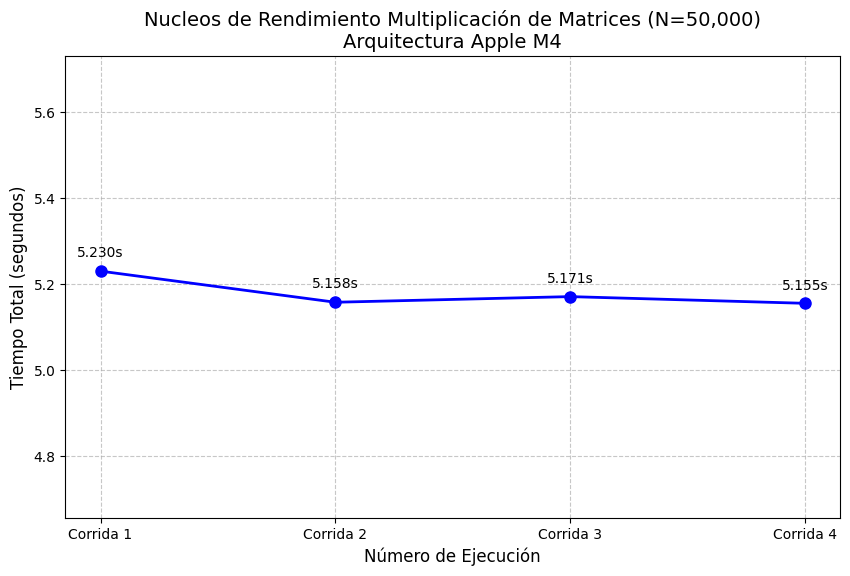

In [58]:
import matplotlib.pyplot as plt

# Datos proporcionados
ejecuciones = ['Corrida 1', 'Corrida 2', 'Corrida 3', 'Corrida 4']
tiempos = [5.230267, 5.157856, 5.170989, 5.155396]

# Configuración de la gráfica
plt.figure(figsize=(10, 6))
plt.plot(ejecuciones, tiempos, marker='o', linestyle='-', color='b', linewidth=2, markersize=8)

# Añadir etiquetas de datos sobre cada punto
for i, txt in enumerate(tiempos):
    plt.annotate(f'{txt:.3f}s', (ejecuciones[i], tiempos[i]), textcoords="offset points", xytext=(0,10), ha='center')

# Estética de la gráfica
plt.title('Nucleos de Rendimiento Multiplicación de Matrices (N=50,000)\nArquitectura Apple M4', fontsize=14)
plt.xlabel('Número de Ejecución', fontsize=12)
plt.ylabel('Tiempo Total (segundos)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.ylim(min(tiempos) - 0.5, max(tiempos) + 0.5) # Ajuste de escala para ver mejor la diferencia

# Mostrar la gráfica
plt.show()